In [1]:
import numpy as np
from matplotlib import pyplot as plt
from kmeans_for_initialization import *

<ins> Initialize the algorithm using the centroids computed from the kmeans algorithm

In [2]:
import numpy as np
def initialize_gmm_with_kmeans(X, n_components):
    n_samples, n_features = X.shape
    
    means, labels = kmeans(X,n_components,50,'euclidean')[:2]
    
    weights = np.zeros(n_components)
    covariances = np.zeros((n_components, n_features, n_features))

    for component in range(n_components):
        cluster = X[labels == component,:]
        weights[component] = cluster.shape[0] / n_samples
        covariances[component] = np.cov(cluster.T)
    
    return(weights, means, covariances)

def initialize_gmm(X, n_components):
    n_samples, n_features = X.shape
    
    # Initialize weights
    weights = np.ones(n_components) / n_components
    
    # Initialize means randomly
    # This step randomly distributes samples to components
    random_indices = np.random.choice(n_samples, n_components, replace=False)
    means = X[random_indices]
    
    # Initialize covariances
    # I start by assuming equal covariance matrices for all comonents
    covariances = np.zeros((n_components, n_features, n_features))
    for k in range(n_components):
        covariances[k] = np.cov(X.T) 
    
    return weights, means, covariances
#############################################################################
def expectation_step(X,k,weights,means, covariances):
    from scipy.stats import multivariate_normal

    nrow, ncol = X.shape
    
    
    #Expectation step
    #Compute the responsibilities
    responsibilities = np.zeros((nrow, k))
    for component in range(k):
        #covariance_array = mean_and_covariance_matrix[1:,:]
        responsibilities[:,component] = weights[component] * multivariate_normal.pdf(X,mean=means[component], cov=covariances[component])
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return(responsibilities)

def maximization_step(X,k,responsibilities):
        nrow, ncol = X.shape
        #Maximization Step
        #in this step the covariance matrix the mean the weights are updatedbased on the responsibilities computed on the expectation step
        N = nrow
        Nk = responsibilities.sum(axis=0)
        responsibilities_times_datapoins_sum = np.dot(responsibilities.T, X) #here each datapoint is multiplied by each responsibility and I get the sum

        #Update weights
        weights = Nk / N #An 1 by 3 array where each entryrepresents the πκ (weight) of the component
        #Update means
        means = responsibilities_times_datapoins_sum / Nk.reshape((k,1)) 

        #Update covariances
        covariances = np.zeros((k, ncol, ncol))

        for component in range(k):
        
            mean = means[component]
            dif_from_mean = X - mean
            k_specific_responsibilities = responsibilities[:,component]

            component_specific_cov = np.dot(k_specific_responsibilities * dif_from_mean.T , dif_from_mean)
            covariances[component] = component_specific_cov / Nk[component]
        return(means, weights, covariances)

<ins> Implement the Gaussina of Mixture Models algorithm

In [3]:
def mixture_of_gausians(X,k,init,iterations):

    import numpy as np
    from scipy.stats import multivariate_normal
    from sklearn.metrics import silhouette_score
    log_likelihood = 0
    likelihood = 0
    its = 0 
    it = 0
    nrow, ncol = X.shape

    if init == 'random':
        weights, means, covariances = initialize_gmm(X,k)
    elif init == 'kmeans':
        weights, means, covariances = initialize_gmm_with_kmeans(X,k)
    else:
        raise ValueError('Input Error. Init should be random or kmeans.')

    log_likelihood = 0
    likelihood = 0
    its = 0 
    it = 0
    while it <iterations:
        responsibilities = expectation_step(X,k,weights,means, covariances)
        means,weights, covariances = maximization_step(X,k,responsibilities)
        it+=1
        
        '''for component in range(k):
            likelihood = weights[component] * multivariate_normal.pdf(X[component], mean=means[component], cov=covariances[component])
            likelihood += likelihood
        updated_log_likelihood = np.log(likelihood)
        if np.abs(updated_log_likelihood - log_likelihood) < 0.00001:
            break
        else:
            log_likelihood = updated_log_likelihood
            its +=1'''
    
    labels = np.argmax(responsibilities,axis = 1)
    
    centroids = np.zeros(shape=(k, ncol))
    for i in range(k):
        centroids[i,:] = np.mean(X[labels==i,:], axis = 0)

    score = silhouette_score(X, labels)
        
    return(centroids, labels, score)

<ins> Generate synthetic data

In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000,n_features=10,centers=4,cluster_std=3.0,random_state=78)

0.2255176239424971


Text(0.5, 1.0, 'GMM centroids')

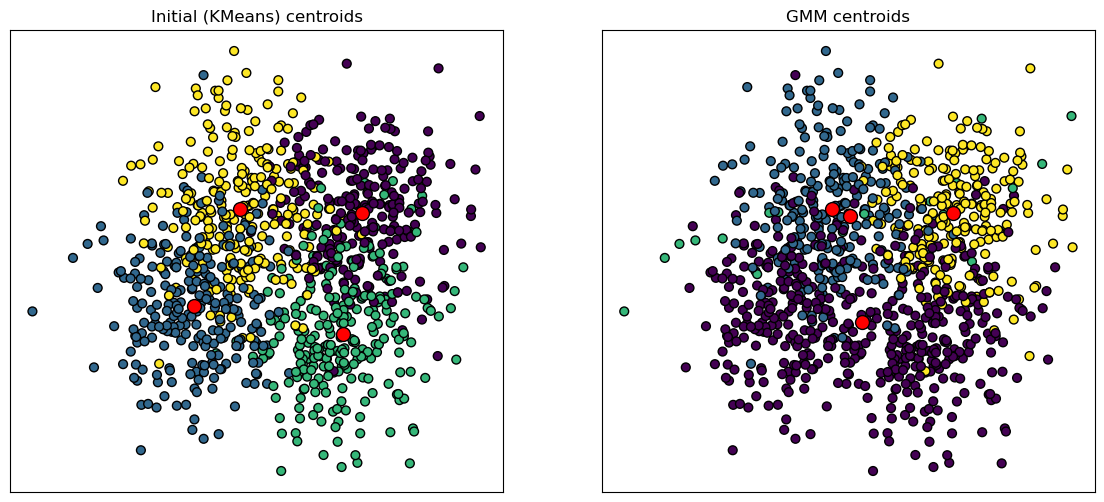

In [13]:

#X = np.random.rand(1000, 2)
k_means_result = kmeans(X,4,50,'manhattan')
centroids = k_means_result[0]
k_means_labels = k_means_result[1]
from matplotlib import pyplot as plt

   

#Plot the results
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (14, 6))

ax1.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = k_means_labels, s=40)
ax1.scatter(centroids[:,0], centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Initial (KMeans) centroids")


gmm_results = mixture_of_gausians(X,4,init= 'random',iterations=1000)
gmm_centroids, gmm_labels , gmm_score= gmm_results
print(gmm_score)
###Plot the result

ax2.scatter(X[:,0], X[:,1], marker = 'o', cmap='viridis', edgecolors='k', c = gmm_labels, s=40)

ax2.scatter(gmm_centroids[:,0], gmm_centroids[:,1],marker='o', c = 'red', s=100,edgecolors='black')

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title("GMM centroids")